In [2]:
import pandas as pd

# Load the raw dataset
df = pd.read_csv("../data/raw/creditcard.csv")

print("Shape:", df.shape)
print("\nColumn data types:\n", df.dtypes)
df.head()

Shape: (284807, 31)

Column data types:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [4]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [6]:
print("Before dropping duplicates:", df.shape)

df = df.drop_duplicates()

print("After dropping duplicates:", df.shape)
print("\nClass distribution after dedup:")
print(df["Class"].value_counts())
print("Fraud percentage: {:.4f}%".format(df["Class"].mean() * 100))

Before dropping duplicates: (284807, 31)
After dropping duplicates: (283726, 31)

Class distribution after dedup:
Class
0    283253
1       473
Name: count, dtype: int64
Fraud percentage: 0.1667%


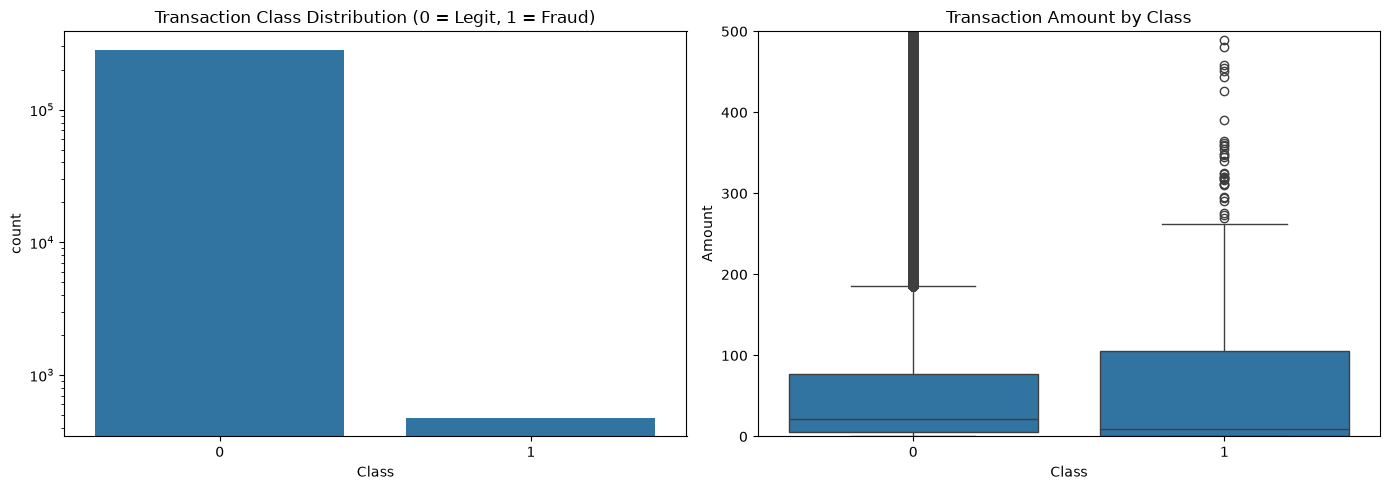

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Class imbalance bar chart
sns.countplot(x="Class", data=df, ax=axes[0])
axes[0].set_title("Transaction Class Distribution (0 = Legit, 1 = Fraud)")
axes[0].set_yscale("log")  # log scale because the imbalance is too extreme for a normal scale

# Plot 2: Amount distribution comparison
sns.boxplot(x="Class", y="Amount", data=df, ax=axes[1])
axes[1].set_title("Transaction Amount by Class")
axes[1].set_ylim(0, 500)  # zoom in, since a few huge outliers would otherwise flatten the plot

plt.tight_layout()
plt.show()

In [5]:
print(df["Class"].value_counts())
print("\nFraud percentage: {:.4f}%".format(df["Class"].mean() * 100))

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


In [8]:
df[["Time", "Amount"]].describe()

,Time,Amount
count,283726.000000,283726.000000
mean,94811.077600,88.472687
std,47481.047891,250.399437
min,0.000000,0.000000
25%,54204.750000,5.600000
50%,84692.500000,22.000000
75%,139298.000000,77.510000
max,172792.000000,25691.160000


In [9]:
import numpy as np

np.random.seed(42)  # reproducibility - same random values every time this runs

n_rows = len(df)
is_fraud = df["Class"].values  # 0 or 1 for each row

# Transaction_Hour: legit skews toward daytime, fraud skews toward late night
legit_hours = np.random.normal(loc=14, scale=5, size=n_rows)   # centered ~2pm
fraud_hours = np.random.normal(loc=3, scale=4, size=n_rows)    # centered ~3am
df["Transaction_Hour"] = np.where(is_fraud == 1, fraud_hours, legit_hours)
df["Transaction_Hour"] = df["Transaction_Hour"].clip(0, 23).round().astype(int)

# Account_Age_Days: legit skews older, fraud skews newer
legit_age = np.random.normal(loc=500, scale=300, size=n_rows)
fraud_age = np.random.normal(loc=40, scale=60, size=n_rows)
df["Account_Age_Days"] = np.where(is_fraud == 1, fraud_age, legit_age)
df["Account_Age_Days"] = df["Account_Age_Days"].clip(0, None).round().astype(int)

# Spending_Deviation: legit near 0 (normal spending), fraud skews higher (unusual amount)
legit_dev = np.random.normal(loc=0.2, scale=0.3, size=n_rows)
fraud_dev = np.random.normal(loc=2.5, scale=1.2, size=n_rows)
df["Spending_Deviation"] = np.where(is_fraud == 1, fraud_dev, legit_dev)
df["Spending_Deviation"] = df["Spending_Deviation"].clip(0, None).round(3)

# Merchant_Risk_Score: 0-1, legit skews low, fraud skews high
legit_merchant = np.random.beta(2, 8, size=n_rows)   # skews low
fraud_merchant = np.random.beta(6, 3, size=n_rows)   # skews high
df["Merchant_Risk_Score"] = np.where(is_fraud == 1, fraud_merchant, legit_merchant).round(3)

# Device_Risk_Score: 0-1, same idea
legit_device = np.random.beta(2, 8, size=n_rows)
fraud_device = np.random.beta(6, 3, size=n_rows)
df["Device_Risk_Score"] = np.where(is_fraud == 1, fraud_device, legit_device).round(3)

df[["Class", "Transaction_Hour", "Account_Age_Days", "Spending_Deviation",
    "Merchant_Risk_Score", "Device_Risk_Score"]].groupby("Class").mean()

,Transaction_Hour,Account_Age_Days,Spending_Deviation,Merchant_Risk_Score,Device_Risk_Score
Class,,,,,
0,13.935739,506.001289,0.244967,0.200303,0.199934
1,3.589852,46.623679,2.460738,0.665368,0.661074


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Define features (X) and target (y)
feature_cols = [col for col in df.columns if col != "Class"]
X = df[feature_cols]
y = df["Class"]

# Split BEFORE scaling, to prevent data leakage
# stratify=y ensures both train and test sets preserve the same ~0.17% fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Fraud rate in train:", y_train.mean())
print("Test shape:", X_test.shape, " Fraud rate in test:", y_test.mean())

# Scale Time and Amount only — the V1-V28 features are already PCA-transformed
# and roughly standardized by construction; our new engineered features are
# already on reasonable, bounded scales (hours 0-23, scores 0-1, etc.)
cols_to_scale = ["Time", "Amount"]

scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit ONLY on training data
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
# Transform test data using the SAME scaler, never re-fit on test data
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

X_train_scaled[cols_to_scale].describe()

Train shape: (226980, 35)  Fraud rate in train: 0.0016653449643140364
Test shape: (56746, 35)  Fraud rate in test: 0.0016741268107003137


,Time,Amount
count,226980.000000,226980.000000
mean,0.118467,0.918890
std,0.557881,3.405863
min,-0.996399,-0.305987
25%,-0.359179,-0.227134
50%,0.000000,0.000000
75%,0.640821,0.772866
max,1.033522,272.096037


In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


In [12]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9998


In [13]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))

Confusion Matrix:
[[56642     9]
 [    1    94]]

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.91      0.99      0.95        95

    accuracy                           1.00     56746
   macro avg       0.96      0.99      0.97     56746
weighted avg       1.00      1.00      1.00     56746



In [14]:
import pandas as pd

coefficients = pd.Series(model.coef_[0], index=feature_cols)
coefficients.abs().sort_values(ascending=False).head(10)

Spending_Deviation     8.515620
Merchant_Risk_Score    5.745816
Device_Risk_Score      5.031312
V25                    1.966982
V24                    1.636341
V27                    1.367852
V28                    1.348349
V4                     0.978668
Transaction_Hour       0.908593
V26                    0.870071
dtype: float64

In [15]:
import joblib
import os

# Create a models directory if it doesn't exist
os.makedirs("../app/ml/artifacts", exist_ok=True)

joblib.dump(model, "../app/ml/artifacts/fraud_model.pkl")
joblib.dump(scaler, "../app/ml/artifacts/scaler.pkl")
joblib.dump(feature_cols, "../app/ml/artifacts/feature_columns.pkl")

print("Model, scaler, and feature column order saved successfully.")

Model, scaler, and feature column order saved successfully.


In [16]:
fraud_example = df[df["Class"] == 1].iloc[0][feature_cols].to_dict()
print(fraud_example)

{'Time': 406.0, 'V1': -2.3122265423263, 'V2': 1.95199201064158, 'V3': -1.60985073229769, 'V4': 3.9979055875468, 'V5': -0.522187864667764, 'V6': -1.42654531920595, 'V7': -2.53738730624579, 'V8': 1.39165724829804, 'V9': -2.77008927719433, 'V10': -2.77227214465915, 'V11': 3.20203320709635, 'V12': -2.89990738849473, 'V13': -0.595221881324605, 'V14': -4.28925378244217, 'V15': 0.389724120274487, 'V16': -1.14074717980657, 'V17': -2.83005567450437, 'V18': -0.0168224681808257, 'V19': 0.416955705037907, 'V20': 0.126910559061474, 'V21': 0.517232370861764, 'V22': -0.0350493686052974, 'V23': -0.465211076182388, 'V24': 0.320198198514526, 'V25': 0.0445191674731724, 'V26': 0.177839798284401, 'V27': 0.261145002567677, 'V28': -0.143275874698919, 'Amount': 0.0, 'Transaction_Hour': 3.0, 'Account_Age_Days': 2.0, 'Spending_Deviation': 3.724, 'Merchant_Risk_Score': 0.495, 'Device_Risk_Score': 0.71}
